In [90]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import sklearn
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import geopandas as gpd

In [72]:
# Load dataset
df = pd.read_csv("data/merged_dengue_dataset.csv")

In [73]:
## Preprocessing
# Drop rows with missing TAT
df_clean = df.dropna(subset=["pre_median_turnaround_days"]).copy()

# Drop redundant columns
cols_to_drop = [
    'post_cases', 'post_genome_count', 'post_genomes_per_1000',
    'post_median_turnaround_days', 'overall_median_turnaround_days',
    'pre_genomes_per_1000', 'pre_cases', 'pre_genome_count',
    'treatment_Publicfrac_pred_high', 'treatment_Publicfrac_pred_low',
    'risk_DCZ_pop_risk_upper', 'risk_DCZ_pop_risk_lower',
    'risk_YF_pop_risk_upper', 'risk_YF_pop_risk_lower',
    'income',  # drop income since it's a duplicate of group
    'gdp_gdp_usd_mean'  # keep only PPP GDP
]
df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], inplace=True)

# Helper to configure OneHotEncoder
def make_ohe(drop_arg):
    params = {"drop": drop_arg}
    # ensure dense output
    if sklearn.__version__ >= "1.2":
        params["sparse_output"] = False
    else:
        params["sparse"] = False
    return OneHotEncoder(**params)

# One-hot encode 'group' (dropping the first level)
ohe_group = make_ohe(drop_arg="first")
group_ohe = ohe_group.fit_transform(df_clean[["group"]])
group_cols = ohe_group.get_feature_names_out(["group"])
group_df = pd.DataFrame(group_ohe, columns=group_cols, index=df_clean.index)

# One-hot encode 'Risk' (dropping 'none' as the baseline)
ohe_risk = make_ohe(drop_arg=["none"])
risk_ohe = ohe_risk.fit_transform(df_clean[["Risk"]])
risk_cols = ohe_risk.get_feature_names_out(["Risk"])
risk_df = pd.DataFrame(risk_ohe, columns=risk_cols, index=df_clean.index)

# Combine everything back into one DataFrame
df_encoded = pd.concat(
    [ df_clean.drop(columns=["group", "Risk"]), group_df, risk_df ],
    axis=1
)

# Inspect
print(df_encoded.head())

  country_code  pre_median_turnaround_days income_country_name  \
0          AGO                      1002.5              Angola   
2          ARG                       562.0           Argentina   
3          AUS                      2776.0           Australia   
4          BEN                      1485.5               Benin   
5          BFA                       893.0        Burkina Faso   

  risk_country_name  risk_Surveillance_score  risk_Total_population  \
0            Angola                    0.578                 33.375   
2         Argentina                    0.842                 45.744   
3         Australia                    0.865                 24.222   
4             Benin                    0.596                 13.617   
5      Burkina Faso                    0.322                 21.990   

   risk_DCZ_pop_risk_mean  risk_YF_pop_risk_mean  rd_value    gov_cc  ...  \
0                  28.289                 25.748  0.032290 -1.158571  ...   
2                  39.

In [74]:
# Log-transform TAT
df_encoded['log_TAT'] = np.log(df_encoded['pre_median_turnaround_days'])

In [77]:
# Regression time!

exclude_cols = [
    'country_code', 'income_country_name', 'risk_country_name',
    'pre_median_turnaround_days', 'log_TAT'
]
feature_cols = [
    c for c in df_encoded.columns
    if c not in exclude_cols and df_encoded[c].dtype != "object"
]
X = df_encoded[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df_encoded['log_TAT']

# Build & fit the pipeline
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)
model.fit(X, y)

# Extract the Ridge step
ridge = model.named_steps['ridge']

# Compute predictions and residuals
y_pred    = model.predict(X)
residuals = y - y_pred
df_encoded['TAT_residual'] = residuals

Intercept: 7.247767786006128

Top 10 coefficients (by magnitude):
                  Feature  Coefficient
             TAT_residual     0.444484
                   gov_ge     0.262981
                 rd_value     0.195858
            Risk_sporadic    -0.186211
         gdp_gdp_ppp_mean    -0.183564
    risk_Total_population    -0.176319
treatment_Publicfrac_pred     0.146780
                   gov_cc    -0.129513
                   gov_va     0.126649
                   gov_rq    -0.106287

R^2 score: 0.998
MSE:      0.001


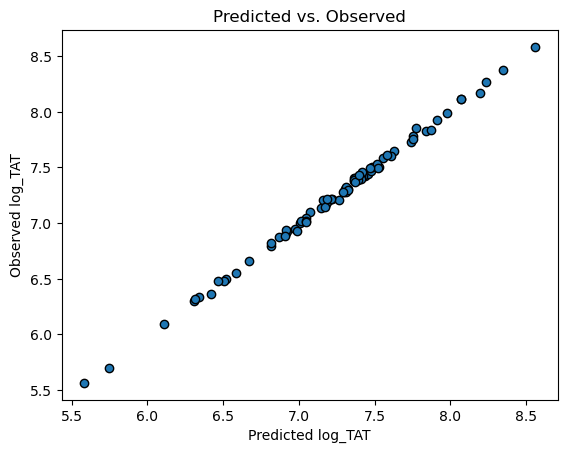

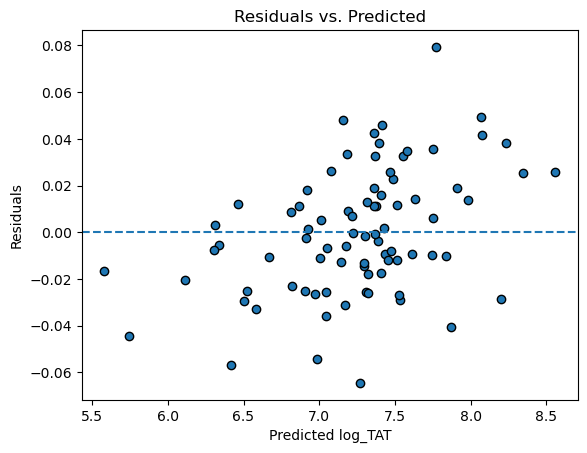

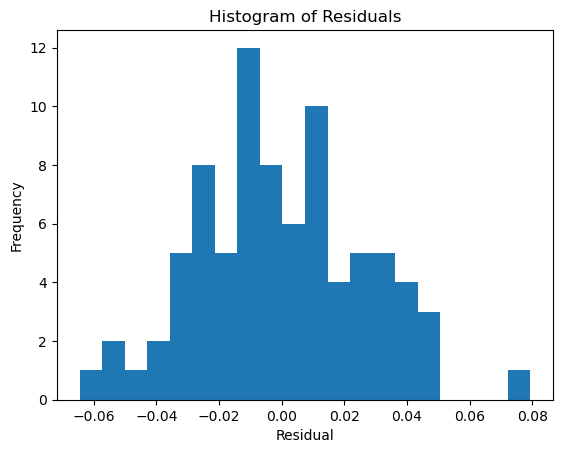

In [78]:
# Now print & plot
print("Intercept:", ridge.intercept_)

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("\nTop 10 coefficients (by magnitude):")
print(coef_df.head(10).to_string(index=False))

print(f"\nR^2 score: {r2_score(y, y_pred):.3f}")
print(f"MSE:      {mean_squared_error(y, y_pred):.3f}")

# a) Predicted vs Observed
plt.figure()
plt.scatter(y_pred, y, edgecolor='k')
plt.xlabel("Predicted log_TAT")
plt.ylabel("Observed log_TAT")
plt.title("Predicted vs. Observed")
plt.show()

# b) Residuals vs Predicted
plt.figure()
plt.scatter(y_pred, residuals, edgecolor='k')
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted log_TAT")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()

# c) Histogram of Residuals
plt.figure()
plt.hist(residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

In [64]:
# Cluster residuals
kmeans = KMeans(n_clusters=3, random_state=42)
df_encoded['TAT_cluster'] = kmeans.fit_predict(df_encoded[['TAT_residual']])

In [65]:
# Print summary
cluster_summary = df_encoded.groupby('TAT_cluster')['pre_median_turnaround_days'].describe()
print(cluster_summary)

# Save clustered data
df_encoded.to_csv("results/clusters/clustered_dengue_TAT.csv", index=False)

             count         mean          std     min      25%      50%  \
TAT_cluster                                                              
0             46.0  1580.945652   605.556486   578.0  1272.75  1503.25   
1             19.0   852.605263   407.860256   261.0   558.00   779.50   
2             17.0  2571.411765  1061.220262  1250.5  1705.50  2409.00   

                 75%     max  
TAT_cluster                   
0            1785.75  4325.0  
1            1073.25  1695.0  
2            3345.00  5351.5  


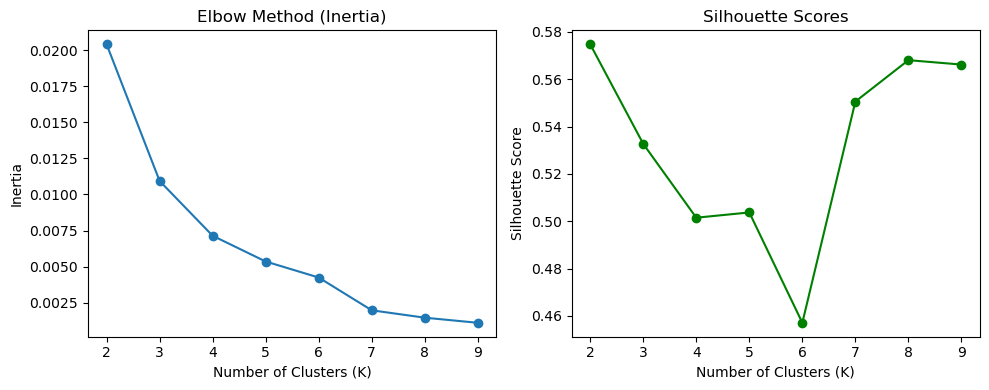

In [79]:
# Elbow and Silhouette Methods
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_encoded[['TAT_residual']])
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(df_encoded[['TAT_residual']], labels))

# Plot Inertia (Elbow)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [84]:
# Time to cluster
cluster_model = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=7, random_state=42)
)

df_encoded['TAT_cluster'] = cluster_model.fit_predict(
    df_encoded[['TAT_residual']]
)

# Summarise and save
summary = df_encoded.groupby('TAT_cluster')['pre_median_turnaround_days'].describe()
print(summary)

df_encoded.to_csv("results/clusters/clustered_dengue_TAT.csv", index=False)

             count         mean          std     min      25%      50%  \
TAT_cluster                                                              
0             11.0  2422.636364  1345.590746  1026.5  1643.75  1820.00   
1             21.0  1395.333333   565.891958   261.0  1093.00  1451.50   
2             16.0  1340.468750   789.054127   442.0   844.75  1114.25   
3             17.0  1351.264706   447.071272   554.0  1018.00  1367.00   
4              1.0  2573.000000          NaN  2573.0  2573.00  2573.00   
5             12.0  2204.208333   864.554890  1345.5  1644.25  1856.50   
6              4.0   810.875000   463.772282   299.0   508.25   800.25   

                  75%     max  
TAT_cluster                    
0            2869.000  5351.5  
1            1705.500  2509.0  
2            1555.750  3528.0  
3            1595.000  2340.0  
4            2573.000  2573.0  
5            2643.000  3912.0  
6            1102.875  1344.0  


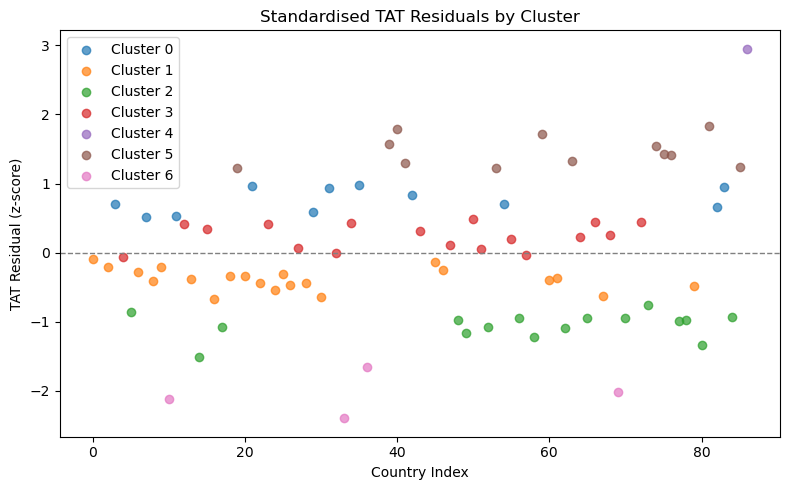

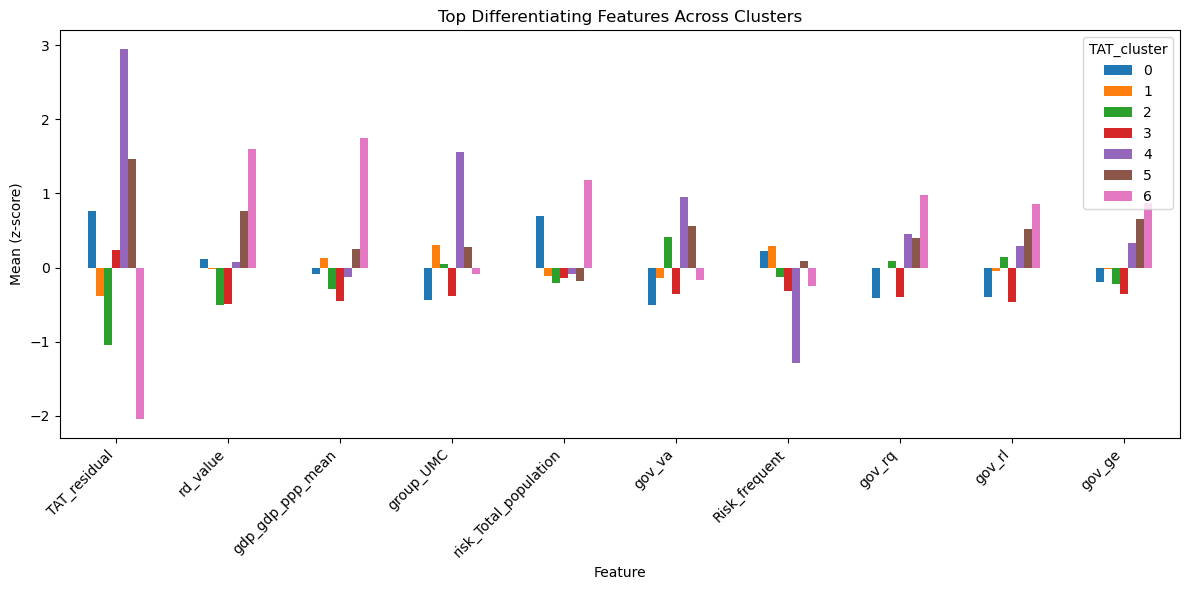

In [92]:
# Standardise the residual and save it
scaler_res = StandardScaler()
df_encoded['TAT_resid_std'] = scaler_res.fit_transform(
    df_encoded[['TAT_residual']]
)

# Plot standardised residuals by cluster
plt.figure(figsize=(8, 5))
for cluster in sorted(df_encoded['TAT_cluster'].unique()):
    sub = df_encoded[df_encoded['TAT_cluster']==cluster]
    plt.scatter(
        sub.index, sub['TAT_resid_std'],
        label=f"Cluster {cluster}", alpha=0.7
    )
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Standardised TAT Residuals by Cluster")
plt.xlabel("Country Index")
plt.ylabel("TAT Residual (z-score)")
plt.legend()
plt.tight_layout()
plt.show()


# Standardise everything
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(
    df_encoded[feature_cols]
)
df_scaled = pd.DataFrame(
    X_scaled, columns=feature_cols, index=df_encoded.index
)

# Recompute cluster‐means on the standardised features
cluster_means_std = (
    df_scaled
    .groupby(df_encoded["TAT_cluster"])
    .mean()
    .T
)

# Pick top‐10 differentiators and plot
top10 = cluster_means_std.std(axis=1) \
                    .sort_values(ascending=False) \
                    .head(10) \
                    .index

cluster_means_std.loc[top10] \
    .plot(kind='bar', figsize=(12,6))
plt.title("Top Differentiating Features Across Clusters")
plt.ylabel("Mean (z-score)")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [89]:
country_clusters = df_encoded[
    ['country_code', 'TAT_cluster',
     'pre_median_turnaround_days',
     'TAT_residual', 'TAT_resid_std']
]
country_clusters_sorted = country_clusters.sort_values(by="TAT_cluster")

print(country_clusters_sorted.to_string(index=False))

country_code  TAT_cluster  pre_median_turnaround_days  TAT_residual  TAT_resid_std
         AUS            0                      2776.0      0.018894       0.701627
         BOL            0                      2962.0      0.013895       0.516000
         CMR            0                      2090.5      0.014305       0.531202
         ERI            0                      5351.5      0.025829       0.959151
         GUF            0                      4325.0      0.025201       0.935824
         GNQ            0                      1679.0      0.016036       0.595498
         KHM            0                      1820.0      0.022601       0.839295
         IND            0                      1213.0      0.026319       0.977361
         NCL            0                      1608.5      0.018933       0.703076
         VEN            0                      1026.5      0.017926       0.665669
         VNM            0                      1797.0      0.025787       0.957605
    

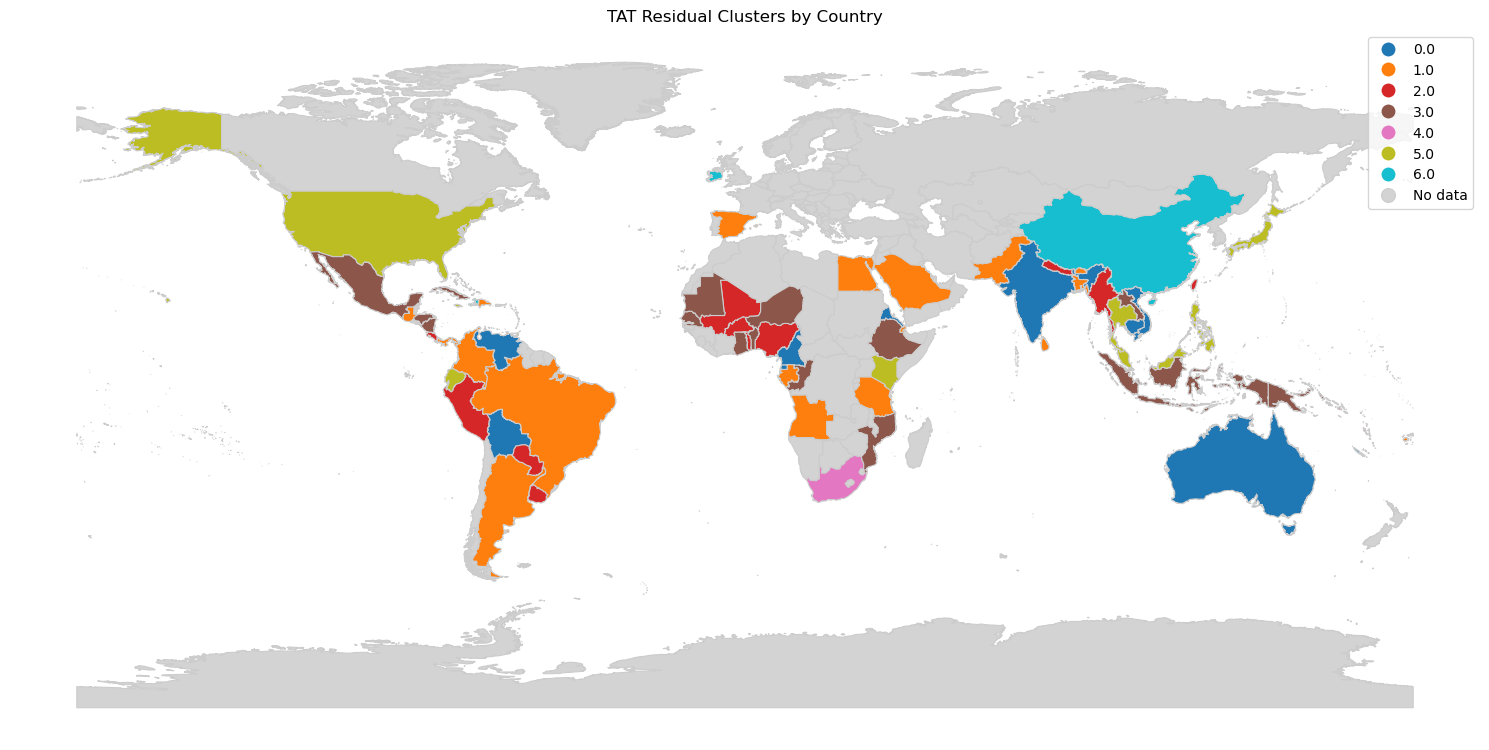

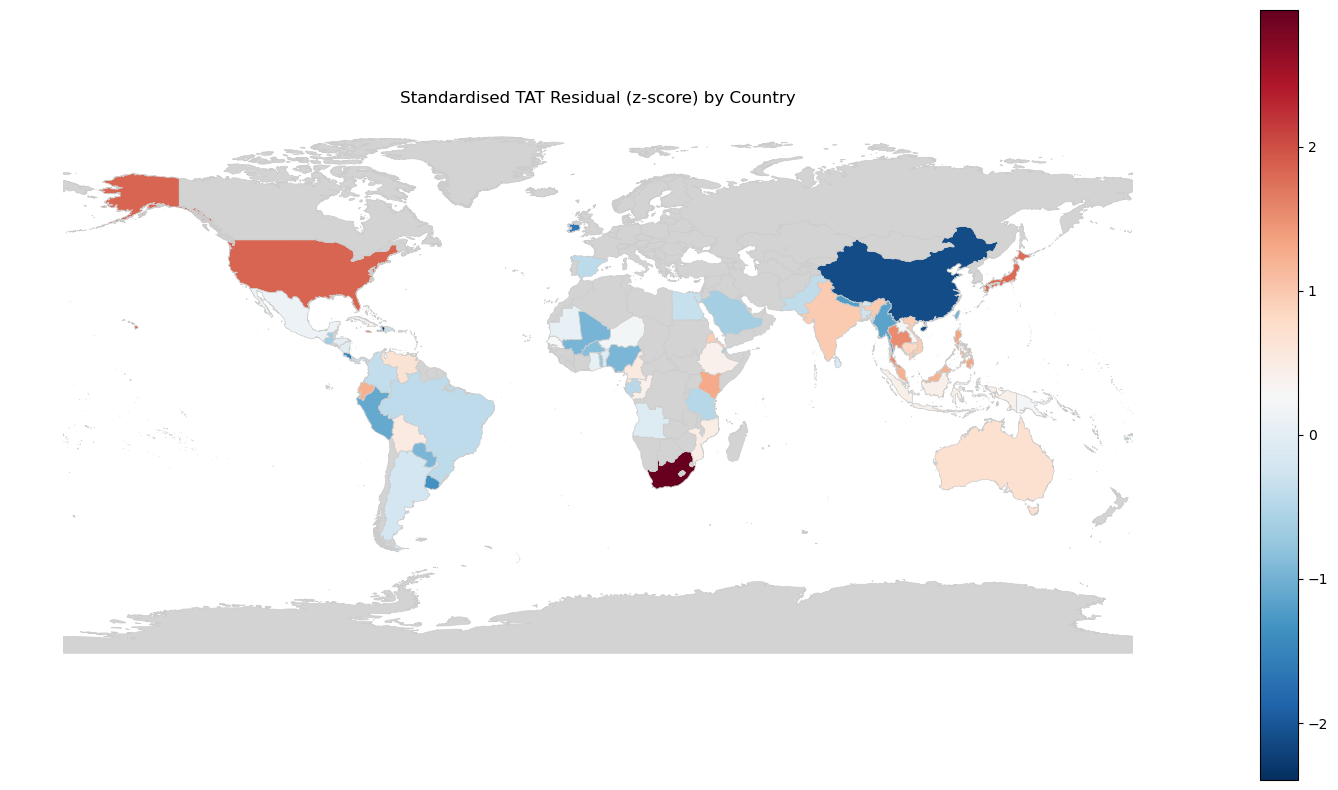

In [91]:
# Build country_clusters with residuals
country_clusters = df_encoded[
    ['country_code', 'TAT_cluster', 'pre_median_turnaround_days',
     'TAT_residual', 'TAT_resid_std']
]

# Load world geometries
url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url)

# Harmonise the ISO3 column
world = world.rename(columns={"ISO_A3": "ISO3166-1-Alpha-3"})

# Merge with clusters & residuals
map_df = world.merge(
    country_clusters,
    left_on="ISO3166-1-Alpha-3",
    right_on="country_code",
    how="left"
)

# Cast cluster to categorical
map_df['TAT_cluster'] = map_df['TAT_cluster'].astype('category')

# Plot 1: Clusters
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
map_df.plot(
    column='TAT_cluster',
    cmap='tab10',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    categorical=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("TAT Residual Clusters by Country")
ax.axis('off')
plt.tight_layout()
plt.show()

# Plot 2: Standardised Residuals
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
map_df.plot(
    column='TAT_resid_std',
    cmap='RdBu_r',       # diverging so positive vs. negative stand out
    linewidth=0.5,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("Standardised TAT Residual (z-score) by Country")
ax.axis('off')
plt.tight_layout()
plt.show()


/Users/oliviawilko/anaconda3/envs/dengue_subsampler/lib/python3.11/site-packages/geopandas/plotting.py:945: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 3
  ax.legend(**legend_kwds)


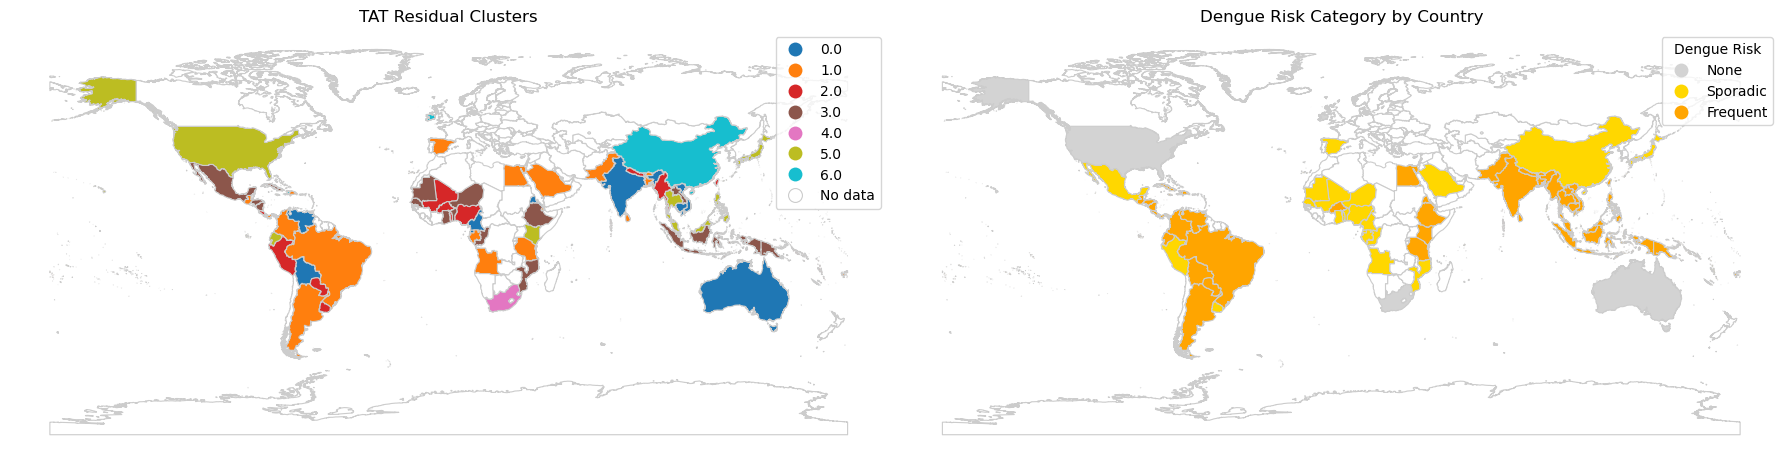

In [98]:
# Reconstruct risk column
df_encoded['Risk'] = 'none'
df_encoded.loc[df_encoded['Risk_frequent'] == 1, 'Risk'] = 'frequent'
df_encoded.loc[df_encoded['Risk_sporadic']  == 1, 'Risk'] = 'sporadic'

# Load & merge world geometries
url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url).rename(columns={"ISO3166-1-Alpha-3": "country_code"})
map_df = world.merge(
    df_encoded[['country_code','TAT_cluster','Risk']],
    on="country_code",
    how="left"
)

# Define a categorical colormap for Risk
risk_categories = ["none", "sporadic", "frequent"]
risk_colors     = ["lightgrey", "#FFD700", "#FFA500"]
cmap = ListedColormap(risk_colors)

# Plot side by side: clusters vs. detailed Risk map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# a) Clusters
map_df.plot(
    column='TAT_cluster',
    cmap='tab10',
    linewidth=0.8,
    ax=ax1,
    edgecolor='0.8',
    legend=True,
    categorical=True,
    missing_kwds={"color": "white", "label": "No data"}
)
ax1.set_title("TAT Residual Clusters")
ax1.axis('off')

# b) Risk categories
map_df['Risk'] = pd.Categorical(map_df['Risk'], categories=risk_categories)
map_df.plot(
    column='Risk',
    cmap=cmap,
    linewidth=0.8,
    ax=ax2,
    edgecolor='0.8',
    legend=True,
    categorical=True,
    legend_kwds={
        'title': 'Dengue Risk',
        'labels': ["None", "Sporadic", "Frequent"]
    },
    missing_kwds={"color": "white", "label": "No country"}
)
ax2.set_title("Dengue Risk Category by Country")
ax2.axis('off')

plt.tight_layout()
plt.show()

In [104]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X = df_encoded[['TAT_resid_std']]

sil = silhouette_score(X, df_encoded['TAT_cluster'])
ch  = calinski_harabasz_score(X, df_encoded['TAT_cluster'])
db  = davies_bouldin_score(X, df_encoded['TAT_cluster'])

print(f"Silhouette score:          {sil:.3f}")
print(f"Calinski–Harabasz index:   {ch:.1f}")
print(f"Davies–Bouldin index:      {db:.3f}")

Silhouette score:          0.551
Calinski–Harabasz index:   363.7
Davies–Bouldin index:      0.434


In [107]:
import bambi as bmb
import arviz as az

# Prepare data
data = df_encoded.copy()
data['TAT_cluster'] = data['TAT_cluster'].astype('category')

# Specify & fit model
model = bmb.Model("pre_median_turnaround_days ~ 1 + TAT_cluster", data)
idata = model.fit(
    draws=2000,
    tune=1000,
    cores=2,
    return_inference_data=True
)

# 3) Summarise the posterior for the cluster effects

summary = az.summary(
    idata,
    var_names=["Intercept", "TAT_cluster"],
    hdi_prob=0.95
)
print(summary)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, Intercept, TAT_cluster]


/Users/oliviawilko/anaconda3/envs/dengue_subsampler/lib/python3.11/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 30 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


                    mean       sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
Intercept       2415.373  243.209  1937.471   2886.329      5.248    3.838   
TAT_cluster[1] -1024.450  302.341 -1654.035   -461.272      5.916    4.542   
TAT_cluster[2] -1075.675  311.507 -1702.842   -481.123      6.141    4.483   
TAT_cluster[3] -1057.698  309.028 -1639.506   -448.076      6.007    4.266   
TAT_cluster[4]   170.979  825.117 -1478.584   1781.891     13.035   12.989   
TAT_cluster[5]  -209.945  333.674  -898.906    415.694      6.432    4.756   
TAT_cluster[6] -1601.362  471.181 -2485.677   -678.712      8.847    6.420   

                ess_bulk  ess_tail  r_hat  
Intercept         2150.0    2555.0    1.0  
TAT_cluster[1]    2616.0    3018.0    1.0  
TAT_cluster[2]    2572.0    3126.0    1.0  
TAT_cluster[3]    2650.0    2872.0    1.0  
TAT_cluster[4]    3996.0    2749.0    1.0  
TAT_cluster[5]    2688.0    2952.0    1.0  
TAT_cluster[6]    2831.0    3067.0    1.0  


In [115]:
# 1) Grab the “vector” of cluster‐deltas and the intercept
post = idata.posterior
intercept = post["Intercept"]          # shape: (chain, draw)
deltas    = post["TAT_cluster"]        # shape: (chain, draw, TAT_cluster_dim)

# 2) See what labels your dim uses (e.g. "T.1", "T.2", …)
print(deltas)

# 3) Build a dict of posterior means for each cluster:
cluster_means = {}
cluster_means["0"] = intercept        # cluster 0 is the reference

for dim_val in deltas.coords["TAT_cluster_dim"].values:
    # dim_val will be something like "T.1" or "T.2"
    k = str(dim_val).split(".")[-1]    # extract the number, e.g. "1"
    cluster_means[k] = intercept + deltas.sel(TAT_cluster_dim=dim_val)

# 4) Compute P(mean_i > mean_j) for your sig pairs:
sig_pairs = [("0","1"), ("0","2"), ("0","3"), ("0","6"), ("5","6")]

for i, j in sig_pairs:
    mean_i = cluster_means[i]
    mean_j = cluster_means[j]
    prob   = float((mean_i > mean_j).values.mean())
    print(f"P(cluster {i} mean > cluster {j} mean) = {prob:.2f}")

<xarray.DataArray 'TAT_cluster' (chain: 2, draw: 2000, TAT_cluster_dim: 6)> Size: 192kB
array([[[-1205.56774453, -1476.70644957, -1324.79158515, -1794.83368395,
          -490.55079425, -2592.52183042],
        [-1312.16890901, -1427.08588877, -1093.34750148,  -859.77498012,
          -979.19180644, -2372.13909762],
        [-1230.57739521, -1065.04823801, -1119.03568998,   490.0840437 ,
          -183.58970296,  -736.9972463 ],
        ...,
        [-1049.54045085, -1353.39575998,  -988.8106853 ,  1142.8779066 ,
          -142.88320624, -1283.82708563],
        [ -963.18836806, -1311.6452088 , -1069.20137315,     6.13799386,
          -130.76359446, -1116.41273231],
        [ -999.15494417, -1382.52831895, -1332.46364781,  -660.18851123,
          -261.55314477, -1559.56774422]],

       [[-1349.38512145, -1268.47886933, -1148.18973381, -1252.47700258,
          -321.41589454, -1458.22883601],
        [ -846.50191541,  -922.84798207,  -675.46348711,  1356.29270681,
           400.6391

In [119]:
# Grab posterior draws
post      = idata.posterior
intercept = post["Intercept"]          
deltas    = post["TAT_cluster"]        

# Build posterior mean DataArrays for each cluster
cluster_means = {"0": intercept}
for dim_val in deltas.coords["TAT_cluster_dim"].values:
    k = str(dim_val)
    cluster_means[k] = intercept + deltas.sel(TAT_cluster_dim=dim_val)

# These were found significant with Tukey
sig_pairs = [("0","1"), ("0","2"), ("0","3"), ("0","6"), ("5","6")]

print("Pair    95% HDI of Δmean     P(mean_i > mean_j)")
print("----    -----------------     ------------------")
for i, j in sig_pairs:
    diff     = cluster_means[i] - cluster_means[j]
    diff_hdi = az.hdi(diff, hdi_prob=0.95)      # a Dataset with var 'x'

    # Extract the 'x' variable, then sel lower/upper, then take the scalar value
    hdi_da = diff_hdi["x"]                     
    lower   = float(hdi_da.sel(hdi="lower").values)
    upper   = float(hdi_da.sel(hdi="higher").values)

    prob    = float((diff > 0).values.mean())

    print(f"{i} vs {j}   [{lower:8.1f}, {upper:8.1f}]     {prob:6.2f}")

Pair    95% HDI of Δmean     P(mean_i > mean_j)
----    -----------------     ------------------
0 vs 1   [   461.3,   1654.0]       1.00
0 vs 2   [   481.1,   1702.8]       1.00
0 vs 3   [   448.1,   1639.5]       1.00
0 vs 6   [   678.7,   2485.7]       1.00
5 vs 6   [   481.1,   2265.5]       1.00
